#1. Import Libraries

In [ ]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
!pip install xgboost lightgbm catboost -q
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_score

!pip install optuna
import optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 20.5 MB/s eta 0:00:00


# 2. Load Data

In [ ]:
train = pd.read_csv("/content/drive/MyDrive/House Prices/Data/train.csv")
test = pd.read_csv("/content/drive/MyDrive/House Prices/Data/test.csv")
sample_submission = pd.read_csv("/content/drive/MyDrive/House Prices/Data/sample_submission.csv")

#3. Initial Data Exploration

## 3.1 Dataset Shape

In [ ]:
print(f"Train Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")

Train Shape : (1460, 81)
Test Shape  : (1459, 80)


## 3.2 First Look

In [ ]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## 3.3 Dataset Information

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 3.4 Statistical Summary

### Numerical Features

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### Categorical Features

In [ ]:
train.describe(include="object").T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


## 3.5 Observation

- The training dataset contains 1460 observations and 81 features.
- The testing dataset contains 1459 observations and 80 features.
- The target variable is SalePrice, which exists only in the training dataset.
- The dataset contains both numerical and categorical features.
- Several features appear to contain missing values and will be investigated later.

# 4. Data Quality Assessment

In [ ]:
quality_report = pd.DataFrame({

    "Data Type": train.dtypes,

    "Missing Values": train.isnull().sum(),

    "Missing %": round(train.isnull().mean() * 100, 2),

    "Unique Values": train.nunique()

})

quality_report

,Data Type,Missing Values,Missing %,Unique Values
Id,int64,0,0.00,1460
MSSubClass,int64,0,0.00,15
MSZoning,object,0,0.00,5
LotFrontage,float64,259,17.74,110
LotArea,int64,0,0.00,1073
Street,object,0,0.00,2
Alley,object,1369,93.77,2
LotShape,object,0,0.00,4
LandContour,object,0,0.00,4
Utilities,object,0,0.00,2


In [ ]:
quality_report = quality_report.sort_values(
    by="Missing %",
    ascending=False
)

quality_report

,Data Type,Missing Values,Missing %,Unique Values
PoolQC,object,1453,99.52,3
MiscFeature,object,1406,96.30,4
Alley,object,1369,93.77,2
Fence,object,1179,80.75,4
MasVnrType,object,872,59.73,3
FireplaceQu,object,690,47.26,5
LotFrontage,float64,259,17.74,110
GarageQual,object,81,5.55,5
GarageFinish,object,81,5.55,3
GarageType,object,81,5.55,6


In [ ]:
print(f"Duplicate Rows : {train.duplicated().sum()}")

Duplicate Rows : 0


- so there is no Duplicates

# 5. Feature Understanding

## Group 1: Location & Land Features

### Features

- MSSubClass
- MSZoning
- LotFrontage
- LotArea
- Street
- Alley
- LotShape
- LandContour
- Utilities
- LotConfig
- LandSlope
- Neighborhood
- Condition1
- Condition2

### Notes

- These features describe the location of the property and the land characteristics.
- Several variables measure the quality of the land, road access, zoning, and neighborhood.
- Neighborhood is expected to be one of the most important predictors because house prices are highly influenced by location.
- Missing values in columns such as Alley usually mean the property does not have an alley, not that the data is missing.
- LotArea and LotFrontage are continuous numerical features representing land size.

## Group 2: Building Structure & Construction

### Features

- BldgType
- HouseStyle
- OverallQual
- OverallCond
- YearBuilt
- YearRemodAdd
- RoofStyle
- RoofMatl
- Exterior1st
- Exterior2nd
- MasVnrType
- MasVnrArea
- ExterQual
- ExterCond
- Foundation

### Notes

- This group describes the building structure, construction quality, and materials used in the house.
- OverallQual is expected to be one of the strongest predictors of SalePrice.
- YearBuilt and YearRemodAdd provide valuable information about the age and renovation history of the property.
- Quality-related features (OverallQual, ExterQual) are ordinal features and may benefit from ordinal encoding.
- Missing values in MasVnrType and MasVnrArea likely indicate the absence of masonry veneer rather than missing information.

## Group 3: Basement Features

### Features

- BsmtQual
- BsmtCond
- BsmtExposure
- BsmtFinType1
- BsmtFinSF1
- BsmtFinType2
- BsmtFinSF2
- BsmtUnfSF
- TotalBsmtSF
- BsmtFullBath
- BsmtHalfBath

### Notes

- This group describes the quality, condition, size, and finishing status of the basement.
- Missing values in basement-related categorical features usually indicate that the house has no basement, rather than missing information.
- TotalBsmtSF is expected to be one of the most important numerical features because larger basement areas generally increase house value.
- Basement quality features (BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2) are ordinal categorical features and may benefit from ordinal encoding.
- Basement finished area and total basement area can be combined to create new engineered features, such as the total finished basement area or the percentage of finished basement space.

## Group 4: Interior Features

### Features

- Heating
- HeatingQC
- CentralAir
- Electrical
- 1stFlrSF
- 2ndFlrSF
- LowQualFinSF
- GrLivArea
- FullBath
- HalfBath
- BedroomAbvGr
- KitchenAbvGr
- KitchenQual
- TotRmsAbvGrd
- Functional
- Fireplaces
- FireplaceQu

### Notes

- This group describes the interior living space, heating system, room layout, and overall functionality of the house.

- GrLivArea is expected to be one of the strongest predictors of SalePrice because it directly measures the living area above ground.

- HeatingQC, KitchenQual, and Functional are ordinal features representing quality levels and may benefit from ordinal encoding.

- Missing values in FireplaceQu indicate that the house does not have a fireplace rather than missing information.

- Bathroom counts and total rooms describe the usability and size of the interior, which are likely to influence house prices.

## Group 5: Garage Features

### Features

- GarageType
- GarageYrBlt
- GarageFinish
- GarageCars
- GarageArea
- GarageQual
- GarageCond

### Notes

- This group describes the garage characteristics, including its location, size, quality, and condition.

- GarageCars and GarageArea are expected to be strong predictors because larger garages are generally associated with more expensive houses.

- GarageFinish, GarageQual, and GarageCond are ordinal features representing garage quality and may benefit from ordinal encoding.

- Missing values in garage-related features usually indicate that the property does not have a garage rather than missing information.

- GarageYrBlt provides additional information about whether the garage was built together with the house or added later.

## Group 6: Outdoor Features

### Features

- PavedDrive
- WoodDeckSF
- OpenPorchSF
- EnclosedPorch
- 3SsnPorch
- ScreenPorch
- PoolArea
- PoolQC
- Fence
- MiscFeature
- MiscVal

### Notes

- This group describes the outdoor amenities and external spaces surrounding the house.

- Features such as WoodDeckSF, OpenPorchSF, and PoolArea measure the size of outdoor living spaces that may increase the property's value.

- PoolQC, Fence, and MiscFeature contain many missing values, which usually indicate that the corresponding feature does not exist rather than missing information.

- PavedDrive indicates the quality of driveway access and may have a moderate impact on house prices.

- Many outdoor area features contain a large number of zero values because many houses simply do not have these facilities.

## Group 7: Sale Information

### Features

- MoSold
- YrSold
- SaleType
- SaleCondition

### Notes

- This group contains information about when and how the property was sold rather than describing the house itself.

- SaleType and SaleCondition may significantly affect the final selling price because some sales occur under special conditions such as family transfers, foreclosures, or newly constructed homes.

- MoSold and YrSold capture temporal information that may reflect changes in the housing market over time.

- These features provide useful market context in addition to the physical characteristics of the property.

# 6.0 EDA by ydata_profiling

In [ ]:
!pip install ydata-profiling

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    train,
    title="House Prices EDA",
    explorative=True
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


 15%|█▍        | 12/81 [00:00<00:05, 13.73it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

100%|██████████| 81/81 [00:05<00:00, 14.70it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Buffered data was truncated after reaching the output size limit.

# 6.1 Decition from EDA

## Group1

### Drop:
- Street
-  Utilities
- Condition2
### OneHot:
- MSSubClass
- LandContour
- MSZoning
- LotConfig
- Neighborhood
- Condition1
### Ordinal:
- LotShape
- LandSlope
### Missing
- fill LotFrontage by mean and keep
- fill Alley
### Keep:
- LotArea
### FeatureEng:
- HasAlley from Alley then Drop
- LotDepth=LotArea / LotFrontage then keep
- IsPremiumNeighborhood from Neighborhood then keep

## Group 2

### Drop:
- RoofMatl

### One-Hot Encoding:
- BldgType
- HouseStyle
- RoofStyle
- Exterior1st
- Exterior2nd
- MasVnrType
- Foundation

### Ordinal Encoding:
- ExterQual
- ExterCond

### Missing:
- MasVnrType → "None"
- MasVnrArea → 0 if MasVnrType=None

### Feature Engineering:
- OverallQuality
- HouseAge = YrSold - YearBuilt
- RemodAge = YrSold - YearRemodAdd
- IsRemodeled
- OverallExterQuality
- HasMasonry (Keep MasVnrType)

### Drop after Feature Engineering:
- YearBuilt
- YearRemodAdd

## Group 3



### Ordinal Encoding
(Missing = 0)

- BsmtQual
- BsmtCond
- BsmtExposure
- BsmtFinType1
- BsmtFinType2

### Keep

- BsmtFinSF1
- BsmtFinSF2
- BsmtUnfSF
- TotalBsmtSF

### Feature Engineering

- HasBsmt
- OverallBsmtQuality = BsmtQual + BsmtCond
- FinishedBsmtRatio =
(BsmtFinSF1 + BsmtFinSF2) / TotalBsmtSF
- TotalBsmtBath =
BsmtFullBath + 0.5 × BsmtHalfBath then Drop BsmtFullBath&BsmtHalfBath

## Group4



### Drop
- Heating
- LowQualFinSF

### One-Hot
- Electrical

### Ordinal

- HeatingQC
- KitchenQual
- Functional
- FireplaceQu missing=0 and encoding begin from 1

### Binary
- CentralAir (0/1)

### Missing
- Electrical → Mode

### Keep
- 1stFlrSF
- GrLivArea
- BedroomAbvGr
- KitchenAbvGr
- TotRmsAbvGrd
- Fireplaces

### Feature Engineering
- Has2ndFlr
- TotalBaths =FullBath + 0.5 × HalfBath
- FireplaceScore

then Drop FullBath&HalfBath

## Group 5



### One-Hot

- GarageType
- Missing = "None"

### Ordinal

- GarageFinish  missing=0 and encoding begin from 1
- GarageQual
- GarageCond

Missing = 0
Encoding from 1

### Keep
- GarageCars
- GarageArea

### Feature Engineering

- GarageAge→ Drop GarageYrBlt

- OverallGarageQuality
- LargeGarage

- GarageCapacityRatio =GarageArea / GarageCars
(if GarageCars == 0 → 0)

## Group 6

### Drop
- 3SsnPorch
- MiscVal

### Ordinal
- PavedDrive

### Keep
- WoodDeckSF
- OpenPorchSF
- EnclosedPorch
### Feature Engineering
- HasWoodDeck
- HasEnclosed
- HasScreenPorch→ Drop ScreenPorch
- HasPool→ Drop PoolArea→ Drop PoolQC
- HasFence→ Drop Fence
- HasMisc→ Drop MiscFeature
- TotalOutdoorArea =WoodDeckSF +OpenPorchSF +EnclosedPorch
### fill
- PoolQC no
- Fence no
- MiscFeature None

## Group 7

### Keep
- YrSold
### One-Hot Encoding
- SaleType
- SaleCondition
### Cyclical Encoding
- MoSold then Drop MoSold

# 7. Data Cleaning

## Separate target

In [ ]:
X_train = train.drop(columns=["SalePrice"])
y_train = train["SalePrice"]

## Combine train & test

In [ ]:
all_data = pd.concat([X_train, test], axis=0).reset_index(drop=True)

print(all_data.shape)

(2919, 80)


## Drop un ipm cols

In [ ]:
drop_columns = [
    "Street",
    "Utilities",
    "Condition2",
    "RoofMatl",
    "Heating",
    "LowQualFinSF",
    "3SsnPorch",
    "MiscVal"
]

all_data.drop(columns=drop_columns, inplace=True)

## Handle Missing Values

In [ ]:
# Numerical
all_data["LotFrontage"].fillna(all_data["LotFrontage"].mean(), inplace=True)

# Alley
all_data["Alley"].fillna("NoAlley", inplace=True)

# Masonry
all_data["MasVnrType"].fillna("None", inplace=True)

all_data.loc[
    all_data["MasVnrType"] == "None",
    "MasVnrArea"
] = 0

# Basement
bsmt_cols = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

for col in bsmt_cols:
    all_data[col].fillna(0, inplace=True)

# Fireplace
all_data["FireplaceQu"].fillna(0, inplace=True)

# Electrical
all_data["Electrical"].fillna(all_data["Electrical"].mode()[0], inplace=True)

# Garage
all_data["GarageType"].fillna("None", inplace=True)

garage_cols = [
    "GarageFinish",
    "GarageQual",
    "GarageCond"
]

for col in garage_cols:
    all_data[col].fillna(0, inplace=True)

# Pool
all_data["PoolQC"].fillna("NoPool", inplace=True)

# Fence
all_data["Fence"].fillna("NoFence", inplace=True)

# Misc
all_data["MiscFeature"].fillna("None", inplace=True)

In [ ]:
missing = all_data.isnull().sum()

missing = missing[missing > 0]

print(missing)

MSZoning          4
Exterior1st       1
Exterior2nd       1
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
KitchenQual       1
Functional        2
GarageYrBlt     159
GarageCars        1
GarageArea        1
SaleType          1
dtype: int64


 - these missing on **Test**

In [ ]:
# Mode
mode_cols = [
    "MSZoning",
    "Exterior1st",
    "Exterior2nd",
    "KitchenQual",
    "Functional",
    "SaleType"
]

for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# Fill with 0
zero_cols = [
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "GarageCars",
    "GarageArea"
]

for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

In [ ]:
all_data.isnull().sum()[all_data.isnull().sum() > 0]

,0
GarageYrBlt,159


- after Feature Eng will deleted

# 8. UnEncoded Feature Engineering

## Group1

In [ ]:
# HasAlley
all_data["HasAlley"] = (all_data["Alley"] != "NoAlley").astype(int)

# LotDepth
all_data["LotDepth"] = all_data["LotArea"] / all_data["LotFrontage"]

# Drop Alley
all_data.drop(columns=["Alley"], inplace=True)

In [ ]:
# Average SalePrice for each neighborhood
neighborhood_price = (
    train.groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
)

print(neighborhood_price)

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64


In [ ]:
# IsPremiumNeighborhood
premium_neighborhoods = [
    "NoRidge",
    "NridgHt",
    "StoneBr",
    "Timber",
    "Veenker",
]

all_data["IsPremiumNeighborhood"] = (
    all_data["Neighborhood"]
    .isin(premium_neighborhoods)
    .astype(int)
)

### check

In [ ]:
new_features = [
    "HasAlley",
    "LotDepth",
    "IsPremiumNeighborhood",
]

display(all_data[new_features].head())

print()

print("Alley" in all_data.columns)


,HasAlley,LotDepth,IsPremiumNeighborhood
0,0,130.000000,0
1,0,120.000000,1
2,0,165.441176,0
3,0,159.166667,0
4,0,169.761905,1



False


## Group2

In [ ]:
# House Age
all_data["HouseAge"] = (
    all_data["YrSold"] -
    all_data["YearBuilt"]
)

# Years Since Remodel
all_data["RemodAge"] = (
    all_data["YrSold"] -
    all_data["YearRemodAdd"]
)

# Isremodeled?
all_data["IsRemodeled"] = (
    all_data["YearBuilt"] !=
    all_data["YearRemodAdd"]
).astype(int)

# Has Masonry Veneer
all_data["HasMasonry"] = (
    all_data["MasVnrType"] != "None"
).astype(int)

# then Drop
all_data.drop(
    columns=[
        "YearBuilt",
        "YearRemodAdd"
    ],
    inplace=True
)



### check

In [ ]:
new_features = [
    "HouseAge",
    "RemodAge",
    "IsRemodeled",
    "HasMasonry"
]

display(all_data[new_features].head())

print()

print("YearBuilt" in all_data.columns)
print("YearRemodAdd" in all_data.columns)

,HouseAge,RemodAge,IsRemodeled,HasMasonry
0,5,5,0,1
1,31,31,0,0
2,7,6,1,1
3,91,36,1,0
4,8,8,0,1



False
False


## Group3

In [ ]:
# Has Basement
all_data["HasBsmt"] = (
    all_data["TotalBsmtSF"] > 0
).astype(int)

# Finished Basement Ratio
all_data["FinishedBsmtRatio"] = (
    (all_data["BsmtFinSF1"] + all_data["BsmtFinSF2"]) /
    all_data["TotalBsmtSF"].replace(0, 1)
)

# Houses without basement
all_data.loc[
    all_data["TotalBsmtSF"] == 0,
    "FinishedBsmtRatio"
] = 0

# Total Basement Bathrooms
all_data["TotalBsmtBath"] = (
    all_data["BsmtFullBath"] +
    0.5 * all_data["BsmtHalfBath"]
)

# then Drop
all_data.drop(
    columns=[
        "BsmtFullBath",
        "BsmtHalfBath"
    ],
    inplace=True
)

### check

In [ ]:
new_features = [
    "HasBsmt",
    "FinishedBsmtRatio",
    "TotalBsmtBath"
]

display(all_data[new_features].head())

print()

print("BsmtFullBath" in all_data.columns)
print("BsmtHalfBath" in all_data.columns)

,HasBsmt,FinishedBsmtRatio,TotalBsmtBath
0,1,0.824766,1.0
1,1,0.774960,0.5
2,1,0.528261,1.0
3,1,0.285714,1.0
4,1,0.572052,1.0



False
False


## Group4

In [ ]:
# Has Second Floor
all_data["Has2ndFlr"] = (
    all_data["2ndFlrSF"] > 0
).astype(int)

# Total Bathrooms
all_data["TotalBaths"] = (
    all_data["FullBath"] +
    0.5 * all_data["HalfBath"]
)

#then Drop
all_data.drop(
    columns=[
        "FullBath",
        "HalfBath"
    ],
    inplace=True
)

### check

In [ ]:
new_features = [
    "Has2ndFlr",
    "TotalBaths"
]

display(all_data[new_features].head())

print()

print("FullBath" in all_data.columns)
print("HalfBath" in all_data.columns)

,Has2ndFlr,TotalBaths
0,1,2.5
1,0,2.0
2,1,2.5
3,1,1.0
4,1,2.5



False
False


## Group5

In [ ]:
# Garage Age
all_data["GarageAge"] = np.where(
    all_data["GarageType"] == "None",
    0,
    all_data["YrSold"] - all_data["GarageYrBlt"]
)

# Large Garage
all_data["LargeGarage"] = (
    all_data["GarageCars"] >= 2
).astype(int)

# Garage Area per Car
all_data["GarageCapacityRatio"] = np.where(
    all_data["GarageCars"] > 0,
    all_data["GarageArea"] / all_data["GarageCars"],
    0
)

#the Drop
all_data.drop(
    columns=["GarageYrBlt"],
    inplace=True
)

### check

In [ ]:
new_features = [
    "GarageAge",
    "LargeGarage",
    "GarageCapacityRatio"
]

display(all_data[new_features].head())

print()

print("GarageYrBlt" in all_data.columns)

,GarageAge,LargeGarage,GarageCapacityRatio
0,5.0,1,274.000000
1,31.0,1,230.000000
2,7.0,1,304.000000
3,8.0,1,214.000000
4,8.0,1,278.666667



False


## Group6

In [ ]:
# Has Wood Deck
all_data["HasWoodDeck"] = (
    all_data["WoodDeckSF"] > 0
).astype(int)

# Has Enclosed Porch
all_data["HasEnclosed"] = (
    all_data["EnclosedPorch"] > 0
).astype(int)

# Has Screen Porch
all_data["HasScreenPorch"] = (
    all_data["ScreenPorch"] > 0
).astype(int)

# Has Pool
all_data["HasPool"] = (
    all_data["PoolArea"] > 0
).astype(int)

# Has Fence
all_data["HasFence"] = (
    all_data["Fence"] != "NoFence"
).astype(int)

# Has Misc Feature
all_data["HasMisc"] = (
    all_data["MiscFeature"] != "None"
).astype(int)

# Total Outdoor Area
all_data["TotalOutdoorArea"] = (
    all_data["WoodDeckSF"] +
    all_data["OpenPorchSF"] +
    all_data["EnclosedPorch"]
)

#then Drop
all_data.drop(
    columns=[
        "ScreenPorch",
        "PoolArea",
        "PoolQC",
        "Fence",
        "MiscFeature"
    ],
    inplace=True
)


### check

In [ ]:
new_features = [
    "HasWoodDeck",
    "HasEnclosed",
    "HasScreenPorch",
    "HasPool",
    "HasFence",
    "HasMisc",
    "TotalOutdoorArea"
]

display(all_data[new_features].head())
print()
print("ScreenPorch" in all_data.columns)
print("PoolArea" in all_data.columns)
print("PoolQC" in all_data.columns)
print("Fence" in all_data.columns)
print("MiscFeature" in all_data.columns)

,HasWoodDeck,HasEnclosed,HasScreenPorch,HasPool,HasFence,HasMisc,TotalOutdoorArea
0,0,0,0,0,0,0,61
1,1,0,0,0,0,0,298
2,0,0,0,0,0,0,42
3,0,1,0,0,0,0,307
4,1,0,0,0,0,0,276



False
False
False
False
False


## Group7

- nothing

# 9. Encoding Pipeline

## 9.0 Binary

In [ ]:
binary_features = [
    "CentralAir"
]

##9.1 Ordinal Mapping

In [ ]:
quality_map = {
    0: 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}
quality_cols = [
    "ExterQual",
    "ExterCond",

    "BsmtQual",
    "BsmtCond",

    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",

    "GarageQual",
    "GarageCond"
]
for col in quality_cols:
    all_data[col] = all_data[col].replace(quality_map)


bsmt_exposure_map = {
    0: 0,
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}
all_data["BsmtExposure"] = (
    all_data["BsmtExposure"]
    .replace(bsmt_exposure_map)
)


bsmt_finish_map = {
    0: 0,
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}
for col in ["BsmtFinType1", "BsmtFinType2"]:
    all_data[col] = (
        all_data[col]
        .replace(bsmt_finish_map)
    )


garage_finish_map = {
    0: 0,
    "Unf": 1,
    "RFn": 2,
    "Fin": 3
}
all_data["GarageFinish"] = (
    all_data["GarageFinish"]
    .replace(garage_finish_map)
)


functional_map = {
    "Sal": 1,
    "Sev": 2,
    "Maj2": 3,
    "Maj1": 4,
    "Mod": 5,
    "Min2": 6,
    "Min1": 7,
    "Typ": 8
}
all_data["Functional"] = (
    all_data["Functional"]
    .replace(functional_map)
)


paved_drive_map = {
    "N": 0,
    "P": 1,
    "Y": 2
}
all_data["PavedDrive"] = (
    all_data["PavedDrive"]
    .replace(paved_drive_map)
)


lotshape_map = {
    "IR3": 1,
    "IR2": 2,
    "IR1": 3,
    "Reg": 4
}
all_data["LotShape"] = (
    all_data["LotShape"]
    .replace(lotshape_map)
)


landslope_map = {
    "Sev": 1,
    "Mod": 2,
    "Gtl": 3
}
all_data["LandSlope"] = (
    all_data["LandSlope"]
    .replace(landslope_map)
)


all_data["CentralAir"] = all_data["CentralAir"].map({
    "N": 0,
    "Y": 1
})

In [ ]:
all_data[quality_cols].head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond
0,4,3,4,3,5,4,0,3,3
1,3,3,4,3,5,3,3,3,3
2,4,3,4,3,5,4,3,3,3
3,3,3,3,4,4,4,4,3,3
4,4,3,4,3,5,4,3,3,3


## 9.2 Cyclical Encoding.

In [ ]:
# Cyclical Encoding for Month Sold

all_data["MoSold_sin"] = np.sin(
    2 * np.pi * all_data["MoSold"] / 12
)

all_data["MoSold_cos"] = np.cos(
    2 * np.pi * all_data["MoSold"] / 12
)

# Drop original month
all_data.drop(columns=["MoSold"], inplace=True)

### check

In [ ]:
display(
    all_data[
        [
            "MoSold_sin",
            "MoSold_cos",
            "YrSold"
        ]
    ].head()
)

print("MoSold" in all_data.columns)

,MoSold_sin,MoSold_cos,YrSold
0,8.660254e-01,5.000000e-01,2008
1,5.000000e-01,-8.660254e-01,2007
2,-1.000000e+00,-1.836970e-16,2008
3,8.660254e-01,5.000000e-01,2006
4,-2.449294e-16,1.000000e+00,2008


False


## 9.3 One-HotEncoding

In [ ]:
onehot_features = [
    "MSSubClass",
    "LandContour",
    "MSZoning",
    "LotConfig",
    "Neighborhood",
    "Condition1",

    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "Foundation",

    "Electrical",

    "GarageType",

    "SaleType",
    "SaleCondition"
]

In [ ]:
remaining_features = [
    col for col in all_data.columns
    if col not in onehot_features
]

### Build ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            onehot_features
        )
    ],
    remainder="passthrough"
)

### Encoding

In [ ]:
encoded_data = preprocessor.fit_transform(all_data)

In [ ]:
onehot_names = preprocessor.named_transformers_[
    "onehot"
].get_feature_names_out(onehot_features)

feature_names = list(onehot_names) + remaining_features

In [ ]:
all_data = pd.DataFrame(
    encoded_data,
    columns=feature_names,
    index=all_data.index
)

### check

In [ ]:
print(all_data.shape)

display(all_data.head())

(2919, 216)


,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_120,MSSubClass_150,MSSubClass_160,MSSubClass_180,MSSubClass_190,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Id,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,GrLivArea,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,YrSold,HasAlley,LotDepth,IsPremiumNeighborhood,HouseAge,RemodAge,IsRemodeled,HasMasonry,HasBsmt,FinishedBsmtRatio,TotalBsmtBath,Has2ndFlr,TotalBaths,GarageAge,LargeGarage,GarageCapacityRatio,HasWoodDeck,HasEnclosed,HasScreenPorch,HasPool,HasFence,HasMisc,TotalOutdoorArea,MoSold_sin,MoSold_cos
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0

# 10. Encoded Feature Engineering

In [ ]:
#Group2
all_data["OverallQuality"] = (
    all_data["OverallQual"] +
    all_data["OverallCond"]
)

all_data["OverallExterQuality"] = (
    all_data["ExterQual"] +
    all_data["ExterCond"]
)

#Group3
all_data["OverallBsmtQuality"] = (
    all_data["BsmtQual"] +
    all_data["BsmtCond"]
)

#Group4
all_data["FireplaceScore"] = (
    all_data["Fireplaces"] *    # * Better beacause if no Fireplace then 0
    all_data["FireplaceQu"]
)

#Group5
all_data["OverallGarageQuality"] = (
    all_data["GarageQual"] +
    all_data["GarageCond"]
)

### check

In [ ]:
encoded_features = [
    "OverallQuality",
    "OverallExterQuality",
    "OverallBsmtQuality",
    "FireplaceScore",
    "OverallGarageQuality",
]

display(all_data[encoded_features].head())

,OverallQuality,OverallExterQuality,OverallBsmtQuality,FireplaceScore,OverallGarageQuality
0,12.0,7.0,7.0,0.0,6.0
1,14.0,6.0,7.0,3.0,6.0
2,12.0,7.0,7.0,3.0,6.0
3,12.0,6.0,7.0,4.0,6.0
4,13.0,7.0,7.0,3.0,6.0


#11. Data Revision

In [ ]:
print(all_data.shape)

print(all_data.isnull().sum().sum())

all_data.head()

(2919, 221)
2


,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_120,MSSubClass_150,MSSubClass_160,MSSubClass_180,MSSubClass_190,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Id,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,GrLivArea,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,YrSold,HasAlley,LotDepth,IsPremiumNeighborhood,HouseAge,RemodAge,IsRemodeled,HasMasonry,HasBsmt,FinishedBsmtRatio,TotalBsmtBath,Has2ndFlr,TotalBaths,GarageAge,LargeGarage,GarageCapacityRatio,HasWoodDeck,HasEnclosed,HasScreenPorch,HasPool,HasFence,HasMisc,TotalOutdoorArea,MoSold_sin,MoSold_cos,OverallQuality,OverallExterQuality,OverallBsmtQuality,FireplaceScore,OverallGarageQuality
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0

In [ ]:
all_data.columns[all_data.isnull().any()]

Index(['GarageAge'], dtype='object')

In [ ]:
all_data[all_data["GarageAge"].isnull()][["GarageAge"]]

,GarageAge
2126,NaN
2576,NaN


In [ ]:
all_data["GarageAge"] = all_data["GarageAge"].fillna(0)
print(all_data.isnull().sum().sum())

0


In [ ]:
all_data.select_dtypes(include="object").columns

Index([], dtype='object')

#12. Modelling

### 12.0 Prepare Final Dataset

In [ ]:
# Split
train = all_data.iloc[:len(train)].copy()
test = all_data.iloc[len(train):].copy()


y_log = np.log1p(y_train)

print(train.shape)
print(test.shape)
print(y_train.shape)
print(train.columns.equals(test.columns))

(1460, 221)
(1459, 221)
(1460,)
True


##12.1 Baseline Model

In [ ]:
rf_baseline = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    rf_baseline,
    train,
    y_log,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse = -scores.mean()

print(f"Baseline CV RMSE: {rmse:.5f}")

Baseline CV RMSE: 0.14088


-  Baseline CV RMSE: 0.14088

In [ ]:
rf_baseline.fit(train, y_log)

RandomForestRegressor(n_jobs=-1, random_state=42)

## 12.2 Feature Importance.

### Top Important Features

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": train.columns,
    "Importance": rf_baseline.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(20)

,Feature,Importance
156,OverallQual,0.538353
174,GrLivArea,0.111063
169,TotalBsmtSF,0.045145
183,GarageCars,0.032940
172,1stFlrSF,0.021453
184,GarageArea,0.020651
216,OverallQuality,0.018635
165,BsmtFinSF1,0.015693
195,HouseAge,0.013018
171,CentralAir,0.012496


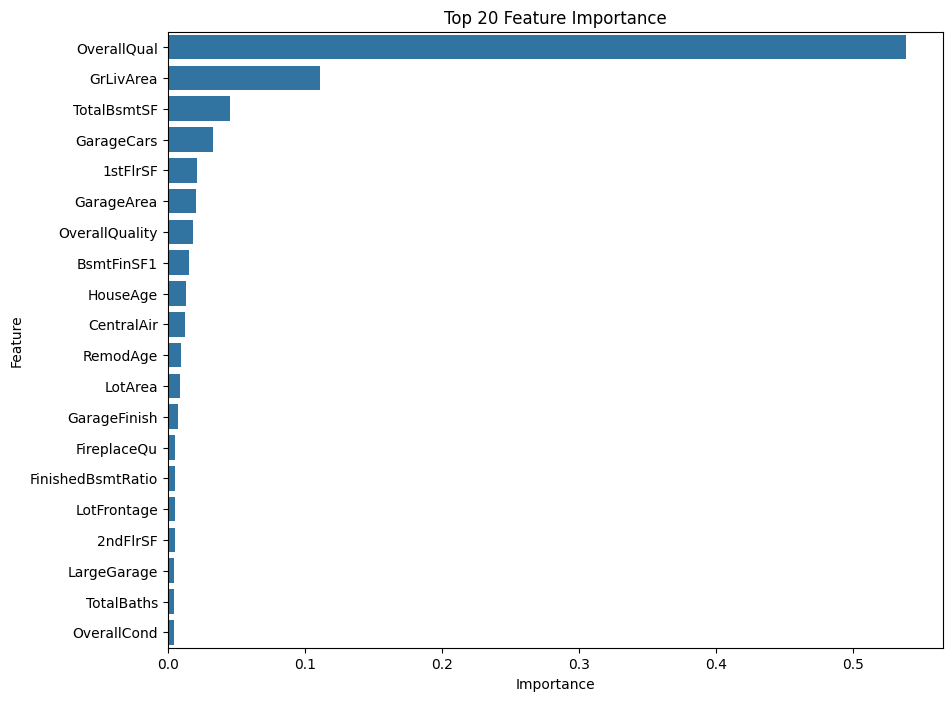

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importance")
plt.show()

### UnImportant Features

In [ ]:
feature_importance[feature_importance["Importance"] < 0.00001]

,Feature,Importance
147,SaleCondition_Alloca,9.317848e-06
32,Neighborhood_BrDale,8.640033e-06
72,HouseStyle_2.5Fin,8.472924e-06
30,Neighborhood_Blmngtn,8.199318e-06
141,SaleType_ConLw,7.904880e-06
14,MSSubClass_180,7.820875e-06
75,HouseStyle_SFoyer,7.382232e-06
137,SaleType_CWD,7.122265e-06
140,SaleType_ConLI,6.871338e-06
63,Condition1_RRNn,6.788572e-06


In [ ]:
len([feature_importance["Importance"] < 0.00001])

1

- so no Feature Selection

## 12.3 Model Selection

In [ ]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

###1. XGBoost

In [ ]:
xgb_model = XGBRegressor(
    random_state=42,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

scores = -cross_val_score(
    xgb_model,
    train,
    y_log,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

print("XGBoost RMSE:", scores.mean())

XGBoost RMSE: 0.12703310902202108


- XGBoost RMSE: 0.12703310902202108

###2. LightGBM

In [ ]:
lgb_model = LGBMRegressor(
    random_state=42,
    n_estimators=1000,
    learning_rate=0.05
)

scores = -cross_val_score(
    lgb_model,
    train,
    y_log,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

print("LightGBM RMSE:", scores.mean())

LightGBM RMSE: 0.13854856482864225


- LightGBM RMSE: 0.13854856482864225

###3. CatBoost

In [ ]:
cat_model = CatBoostRegressor(
    random_state=42,
    iterations=1000,
    learning_rate=0.05,
    verbose=0
)

scores = -cross_val_score(
    cat_model,
    train,
    y_log,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

print("CatBoost RMSE:", scores.mean())

CatBoost RMSE: 0.12564030629266382


CatBoost RMSE: 0.12564030629266382
###-->  the winner model is **CatBoost**

##12.4 HyperParamter Tuning by optuna

In [ ]:
def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 500, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 5),
        "random_strength": trial.suggest_float("random_strength", 0, 5),

        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_state": 42,
        "verbose": 0
    }

    model = CatBoostRegressor(**params)

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    score = -cross_val_score(
        model,
        train,
        y_log,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    ).mean()

    return score

In [ ]:
study = optuna.create_study(direction="minimize")

study.optimize(
    objective,
    n_trials=100
)

[I 2026-07-26 15:35:45,558] A new study created in memory with name: no-name-4ba07ed1-bc30-48b3-8ecf-daac7d4adf67
[I 2026-07-26 15:36:10,403] Trial 0 finished with value: 0.13245827682266317 and parameters: {'iterations': 987, 'learning_rate': 0.2969629333905826, 'depth': 4, 'l2_leaf_reg': 18.632080563754464, 'bagging_temperature': 4.3461220372061895, 'random_strength': 0.5741874078544135}. Best is trial 0 with value: 0.13245827682266317.
[I 2026-07-26 15:40:02,662] Trial 1 finished with value: 0.13272707491003857 and parameters: {'iterations': 2062, 'learning_rate': 0.2135011759024816, 'depth': 8, 'l2_leaf_reg': 7.128130956057506, 'bagging_temperature': 2.3204233707399124, 'random_strength': 4.500359223046352}. Best is trial 0 with value: 0.13245827682266317.
[I 2026-07-26 15:50:07,974] Trial 2 finished with value: 0.13055894207547966 and parameters: {'iterations': 1467, 'learning_rate': 0.0819435872377762, 'depth': 10, 'l2_leaf_reg': 19.66592767244285, 'bagging_temperature': 0.674060

In [ ]:
print("Best RMSE:", study.best_value)

print()

print("Best Params:")
print(study.best_params)

Best RMSE: 0.12294466220026454

Best Params:
{'iterations': 2617, 'learning_rate': 0.02313093787284947, 'depth': 6, 'l2_leaf_reg': 9.03097872708246, 'bagging_temperature': 1.2869686926574988, 'random_strength': 4.770082498847903}


## 12.5 Final Model

In [ ]:
best_model = CatBoostRegressor(
    **study.best_params,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_state=42,
    verbose=0
)

best_model.fit(train, y_log)

CatBoostRegressor(bagging_temperature=1.2869686926574988, depth=6, eval_metric='RMSE', iterations=2617, l2_leaf_reg=9.03097872708246, learning_rate=0.02313093787284947, loss_function='RMSE', random_state=42, random_strength=4.770082498847903, verbose=0)

### Prediction & Submission

In [ ]:
pred_log = best_model.predict(test)

pred = np.expm1(pred_log)

submission = pd.DataFrame({
    "Id": sample_submission["Id"],
    "SalePrice": pred
})

submission.to_csv("submission.csv", index=False)

In [ ]:
submission.shape

(1459, 2)

In [ ]:
(submission["SalePrice"] <= 0).sum()

np.int64(0)

In [ ]:
submission.to_csv("submission.csv", index=False)

# Conclusion

| Model                          | RMSE / Score |
| ------------------------------ | -----------: |
| Random Forest (Baseline)       |  **0.14088** |
| CatBoost + Optuna (100 Trials) |  **0.12294** |
| Kaggle Public Score            |  **0.12738** |


- ✅ Built a complete end-to-end machine learning pipeline.
- ✅ Performed extensive data preprocessing and feature engineering.
- ✅ Compared multiple boosting algorithms (XGBoost, LightGBM, CatBoost).
- ✅ Selected CatBoost as the best-performing model.
- ✅ Optimized hyperparameters using Optuna.
- ✅ Achieved a Cross Validation RMSE of 0.12294.
- ✅ Achieved a Kaggle Public Leaderboard Score of 0.12738, ranking #1602.